# Eksplorasi Dataset HKUST Smart Meter + HKO Open Data

Notebook ini mengikuti arah tugas besar Data Analitik berbasis OSEMN untuk topik **Energi dan Efisiensi Gedung/Kampus**. Urutan notebook:

1. Load dan profil sumber data satu per satu.
2. Eksplorasi biasa untuk HKUST dan HKO secara terpisah.
3. Baru di akhir menggabungkan energi harian HKUST dengan data cuaca HKO.

Catatan praktis: dataset HKUST lengkap berisi ribuan file Excel. Notebook ini menginventarisasi seluruh file dan membaca penuh subset analitik harian T1440, karena itulah interval yang paling sesuai dengan HKO daily climate data. Loader untuk T60 disediakan untuk eksplorasi pola jam pada sampel meter.

## Link Sumber Dataset

| Peran | Dataset | Link |
|---|---|---|
| Utama | A 2.5-year campus-level smart meter database with equipment data for energy analytics | https://doi.org/10.5061/dryad.k3j9kd5h6 |
| Artikel pendukung | Scientific Data paper | https://doi.org/10.1038/s41597-024-04106-1 |
| Pendukung | Hong Kong Observatory Open Data | https://www.weather.gov.hk/en/abouthko/opendata_intro.htm |
| HKO suhu mean Sai Kung | CLMTEMP SKG | https://data.weather.gov.hk/weatherAPI/opendata/opendata.php?dataType=CLMTEMP&rformat=csv&station=SKG |
| HKO suhu max Sai Kung | CLMMAXT SKG | https://data.weather.gov.hk/weatherAPI/opendata/opendata.php?dataType=CLMMAXT&rformat=csv&station=SKG |
| HKO suhu min Sai Kung | CLMMINT SKG | https://data.weather.gov.hk/weatherAPI/opendata/opendata.php?dataType=CLMMINT&rformat=csv&station=SKG |
| HKO kelembapan Sai Kung | daily_SKG_RH_ALL.csv | https://data.weather.gov.hk/weatherAPI/cis/csvfile/SKG/ALL/daily_SKG_RH_ALL.csv |
| HKO hujan Kau Sai Chau | daily_KSC_RF_ALL.csv | https://data.weather.gov.hk/weatherAPI/cis/csvfile/KSC/ALL/daily_KSC_RF_ALL.csv |
| HKO radiasi matahari Kau Sai Chau | daily_KSC_GSR_ALL.csv | https://data.weather.gov.hk/weatherAPI/cis/csvfile/KSC/ALL/daily_KSC_GSR_ALL.csv |
| HKO angin Sai Kung | daily_SKG_WSPD_ALL.csv | https://data.weather.gov.hk/cis/csvfile/SKG/ALL/daily_SKG_WSPD_ALL.csv |

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
HKUST_ROOT = ROOT / "dataset" / "doi_10_5061_dryad_k3j9kd5h6__v20240801"
HKUST_ALL = HKUST_ROOT / "All_Data" / "All Data"
HKO_RAW = ROOT / "dataset" / "hko_open_data" / "raw"
PROCESSED = ROOT / "dataset" / "processed"
PROFILE = ROOT / "dataset" / "profile_hkust_hko"

PROJECT_START = pd.Timestamp("2022-01-01")
PROJECT_END = pd.Timestamp("2024-05-27")

assert HKUST_ROOT.exists(), HKUST_ROOT
assert HKO_RAW.exists(), HKO_RAW
print("Workspace:", ROOT)

Workspace: C:\Users\Khalfani Shaquille\Documents\GitHub\Kelompok08_DataAnalytics_TugasBesar


## 1. Load dan Profil HKO per Dataset

In [2]:
HKO_VARIABLES = {
    "skg_mean_temperature": "mean_temperature_c",
    "skg_max_temperature": "max_temperature_c",
    "skg_min_temperature": "min_temperature_c",
    "skg_relative_humidity": "relative_humidity_pct",
    "ksc_total_rainfall": "rainfall_mm",
    "ksc_global_solar_radiation": "global_solar_radiation_mj_m2",
    "skg_mean_wind_speed": "mean_wind_speed_kmh",
}

def parse_hko_csv(path: Path, value_name: str) -> pd.DataFrame:
    raw = pd.read_csv(path, skiprows=2, header=None, encoding="utf-8-sig")
    raw = raw.iloc[:, :5].copy()
    raw.columns = ["year", "month", "day", value_name, f"{value_name}_completeness"]
    for col in ["year", "month", "day"]:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")
    raw["date"] = pd.to_datetime(
        {"year": raw["year"], "month": raw["month"], "day": raw["day"]},
        errors="coerce",
    )
    raw[value_name] = pd.to_numeric(raw[value_name], errors="coerce")
    return raw[["date", value_name, f"{value_name}_completeness"]]

hko_frames = {}
hko_profile_rows = []
for dataset_id, variable in HKO_VARIABLES.items():
    path = HKO_RAW / f"{dataset_id}.csv"
    df = parse_hko_csv(path, variable)
    project = df[(df["date"] >= PROJECT_START) & (df["date"] <= PROJECT_END)]
    hko_frames[dataset_id] = df
    hko_profile_rows.append({
        "dataset_id": dataset_id,
        "variable": variable,
        "shape": df.shape,
        "start": df["date"].min(),
        "end": df["date"].max(),
        "project_rows": len(project),
        "project_missing": project[variable].isna().sum(),
    })

hko_profile = pd.DataFrame(hko_profile_rows)
hko_profile

,dataset_id,variable,shape,start,end,project_rows,project_missing
0,skg_mean_temperature,mean_temperature_c,"(12087, 3)",1993-04-01,2026-04-30,878,0
1,skg_max_temperature,max_temperature_c,"(12087, 3)",1993-04-01,2026-04-30,878,0
2,skg_min_temperature,min_temperature_c,"(12087, 3)",1993-04-01,2026-04-30,878,0
3,skg_relative_humidity,relative_humidity_pct,"(12087, 3)",1993-04-01,2026-04-30,878,0
4,ksc_total_rainfall,rainfall_mm,"(6486, 3)",2008-08-01,2026-04-30,878,5
5,ksc_global_solar_radiation,global_solar_radiation_mj_m2,"(6486, 3)",2008-08-01,2026-04-30,878,1
6,skg_mean_wind_speed,mean_wind_speed_kmh,"(12087, 3)",1993-04-01,2026-04-30,878,0


In [3]:
# Eksplorasi biasa HKO: statistik deskriptif setiap variabel pada periode proyek.
hko_weather = None
for dataset_id, variable in HKO_VARIABLES.items():
    df = hko_frames[dataset_id][["date", variable, f"{variable}_completeness"]]
    hko_weather = df if hko_weather is None else hko_weather.merge(df, on="date", how="outer")

hko_weather = hko_weather[(hko_weather["date"] >= PROJECT_START) & (hko_weather["date"] <= PROJECT_END)].sort_values("date")
hko_weather["is_rainy_day"] = hko_weather["rainfall_mm"].fillna(0).gt(0).astype(int)
hko_weather["is_hot_day_28c"] = hko_weather["mean_temperature_c"].gt(28).astype(int)
hko_weather["cooling_degree_day_24c"] = (hko_weather["mean_temperature_c"] - 24).clip(lower=0)

value_cols = list(HKO_VARIABLES.values())
display(hko_weather[value_cols].describe().T)
display(hko_weather.head())

,count,mean,std,min,25%,50%,75%,max
mean_temperature_c,878.0,23.219818,5.319491,6.80,18.90,23.90,28.100,32.2
max_temperature_c,878.0,25.801481,5.628609,8.60,21.40,26.20,30.500,35.8
min_temperature_c,878.0,21.098405,5.353887,5.30,16.80,22.20,25.975,29.1
relative_humidity_pct,878.0,79.179954,10.919712,29.00,73.00,81.00,87.000,98.0
rainfall_mm,873.0,5.130584,18.290630,0.00,0.00,0.00,1.000,256.0
global_solar_radiation_mj_m2,877.0,14.125131,7.296315,0.99,7.72,14.55,20.070,28.1
mean_wind_speed_kmh,878.0,9.493850,5.568177,1.70,5.60,8.00,11.900,37.6


,date,mean_temperature_c,mean_temperature_c_completeness,max_temperature_c,max_temperature_c_completeness,min_temperature_c,min_temperature_c_completeness,relative_humidity_pct,relative_humidity_pct_completeness,rainfall_mm,rainfall_mm_completeness,global_solar_radiation_mj_m2,global_solar_radiation_mj_m2_completeness,mean_wind_speed_kmh,mean_wind_speed_kmh_completeness,is_rainy_day,is_hot_day_28c,cooling_degree_day_24c
26886,2022-01-01,16.8,C,19.2,C,14.4,C,78.0,C,0.0,C,7.33,C,6.7,C,0,0,0.0
26887,2022-01-02,16.9,C,20.5,C,13.9,C,82.0,C,0.0,C,16.14,C,6.9,C,0,0,0.0
26888,2022-01-03,17.0,C,19.3,C,15.0,C,84.0,C,0.0,C,13.76,C,3.8,C,0,0,0.0
26889,2022-01-04,18.0,C,21.3,C,14.6,C,80.0,C,0.5,C,15.80,C,6.4,C,1,0,0.0
26890,2022-01-05,19.0,C,22.4,C,17.1,C,82.0,C,0.5,C,16.86,C,5.1,C,1,0,0.0


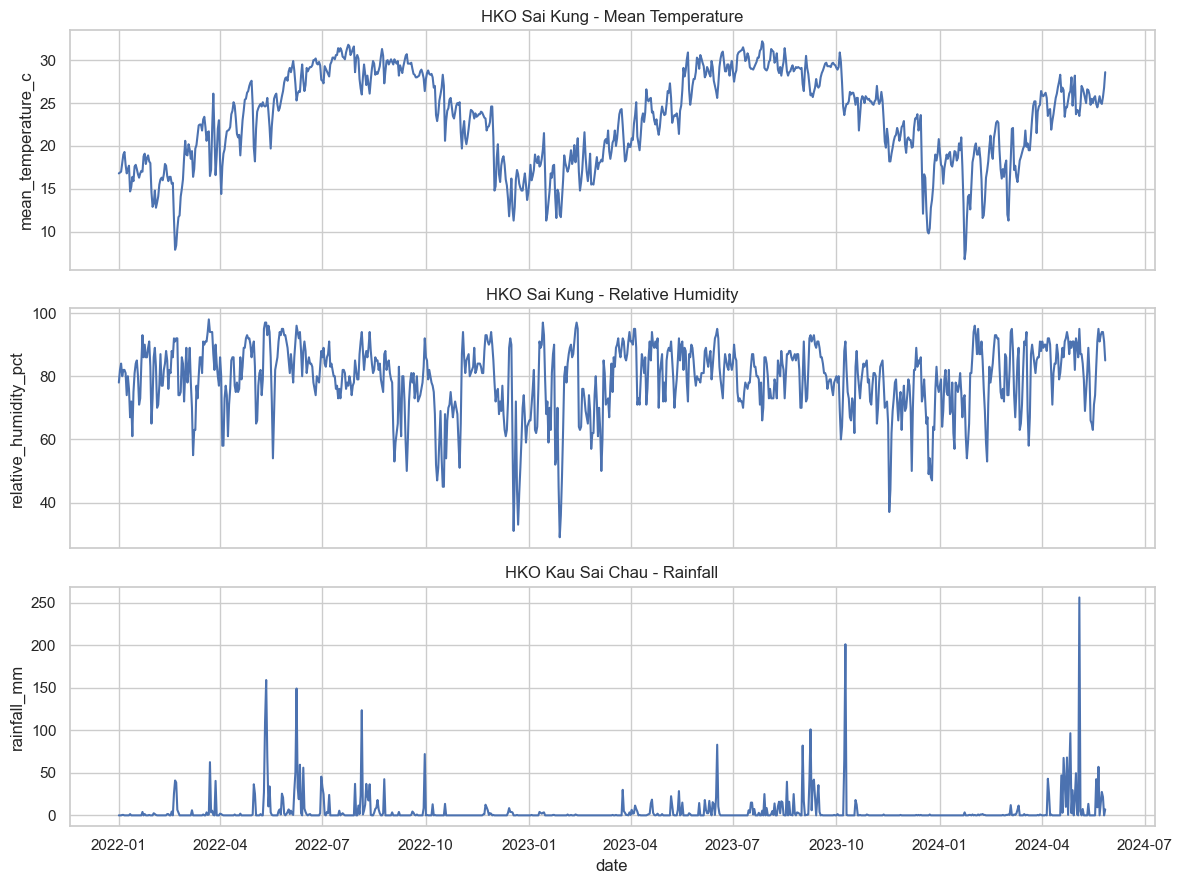

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
sns.lineplot(data=hko_weather, x="date", y="mean_temperature_c", ax=axes[0])
axes[0].set_title("HKO Sai Kung - Mean Temperature")
sns.lineplot(data=hko_weather, x="date", y="relative_humidity_pct", ax=axes[1])
axes[1].set_title("HKO Sai Kung - Relative Humidity")
sns.lineplot(data=hko_weather, x="date", y="rainfall_mm", ax=axes[2])
axes[2].set_title("HKO Kau Sai Chau - Rainfall")
plt.tight_layout()
plt.show()

## 2. Load dan Profil HKUST per Kelompok File

In [5]:
groups = {
    "raw_time_series": HKUST_ALL / "Raw Dataset" / "Time-series data",
    "clean_T15": HKUST_ALL / "Clean Dataset" / "Resappled data" / "T15",
    "clean_T30": HKUST_ALL / "Clean Dataset" / "Resappled data" / "T30",
    "clean_T60": HKUST_ALL / "Clean Dataset" / "Resappled data" / "T60",
    "clean_T1440": HKUST_ALL / "Clean Dataset" / "Resappled data" / "T1440",
}

inventory = []
for group, path in groups.items():
    files = sorted(path.glob("*.xlsx"))
    inventory.append({
        "group": group,
        "path": str(path.relative_to(ROOT)),
        "file_count": len(files),
        "total_mb": round(sum(f.stat().st_size for f in files) / 1024 / 1024, 3),
        "sample_file": files[0].name if files else None,
    })

inventory_df = pd.DataFrame(inventory)
inventory_df

,group,path,file_count,total_mb,sample_file
0,raw_time_series,dataset\doi_10_5061_dryad_k3j9kd5h6__v20240801...,1394,773.253,GUI_NO.D0001.xlsx
1,clean_T15,dataset\doi_10_5061_dryad_k3j9kd5h6__v20240801...,403,408.889,GUI_NO.D0001.xlsx
2,clean_T30,dataset\doi_10_5061_dryad_k3j9kd5h6__v20240801...,645,349.720,GUI_NO.H0004.xlsx
3,clean_T60,dataset\doi_10_5061_dryad_k3j9kd5h6__v20240801...,255,71.921,GUI_NO.D0601.xlsx
4,clean_T1440,dataset\doi_10_5061_dryad_k3j9kd5h6__v20240801...,26,0.426,GUI_NO.D0816.xlsx


In [6]:
# Baca penuh semua file T1440 karena ringan dan cocok untuk gabungan harian.
def load_hkust_group(files, time_col="time", value_col="number"):
    frames = []
    for path in files:
        meter_id = path.stem.replace("GUI_NO.", "")
        df = pd.read_excel(path, engine="openpyxl")
        df = df.rename(columns={df.columns[0]: time_col, df.columns[1]: value_col})
        df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
        df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
        df["meter_id"] = meter_id
        frames.append(df[[time_col, "meter_id", value_col]])
    return pd.concat(frames, ignore_index=True)

t1440_files = sorted(groups["clean_T1440"].glob("*.xlsx"))
hkust_t1440 = load_hkust_group(t1440_files, time_col="date", value_col="meter_reading")
hkust_t1440["date"] = hkust_t1440["date"].dt.normalize()
hkust_t1440 = hkust_t1440.sort_values(["meter_id", "date"])
hkust_t1440["daily_consumption"] = hkust_t1440.groupby("meter_id")["meter_reading"].diff()
hkust_t1440.loc[hkust_t1440["daily_consumption"] < 0, "daily_consumption"] = pd.NA

print("HKUST T1440 shape:", hkust_t1440.shape)
display(hkust_t1440.head())
display(hkust_t1440.groupby("meter_id").agg(
    rows=("date", "size"),
    start=("date", "min"),
    end=("date", "max"),
    missing_reading=("meter_reading", lambda s: s.isna().sum()),
    missing_consumption=("daily_consumption", lambda s: s.isna().sum()),
    min_reading=("meter_reading", "min"),
    max_reading=("meter_reading", "max"),
).reset_index().head(10))

HKUST T1440 shape: (22131, 4)


,date,meter_id,meter_reading,daily_consumption
0,2022-01-01,D0816,9254520.0,NaN
1,2022-01-02,D0816,9256540.0,2020.0
2,2022-01-03,D0816,9258550.0,2010.0
3,2022-01-04,D0816,9260790.0,2240.0
4,2022-01-05,D0816,9263080.0,2290.0


,meter_id,rows,start,end,missing_reading,missing_consumption,min_reading,max_reading
0,D0816,181,2022-01-01,2022-06-30,1,3,9.254520e+06,9.608570e+06
1,D0821,878,2022-01-01,2024-05-27,31,33,0.000000e+00,0.000000e+00
2,D0823,878,2022-01-01,2024-05-27,31,33,0.000000e+00,0.000000e+00
3,D0837,878,2022-01-01,2024-05-27,30,32,2.255290e+05,2.575800e+05
4,D0844,878,2022-01-01,2024-05-27,94,98,0.000000e+00,0.000000e+00
5,D0845,878,2022-01-01,2024-05-27,0,1,1.041810e+05,1.409000e+05
6,D0846,878,2022-01-01,2024-05-27,0,435,1.188240e-01,6.364080e-01
7,D0847,878,2022-01-01,2024-05-27,0,1,0.000000e+00,0.000000e+00
8,D0848,878,2022-01-01,2024-05-27,0,1,6.651600e+06,8.705020e+06
9,D0849,878,2022-01-01,2024-05-27,0,1,8.149000e+06,1.097140e+07


In [7]:
# Load sampel T60 untuk eksplorasi jam. Seluruh file T60 tersedia di inventory,
# tetapi pembacaan penuh semua interval halus sengaja dibuat opsional agar notebook tetap responsif.
t60_files = sorted(groups["clean_T60"].glob("*.xlsx"))
t60_sample = load_hkust_group(t60_files[:8], time_col="timestamp", value_col="meter_reading")
t60_sample = t60_sample.sort_values(["meter_id", "timestamp"])
t60_sample["hourly_consumption"] = t60_sample.groupby("meter_id")["meter_reading"].diff()
t60_sample.loc[t60_sample["hourly_consumption"] < 0, "hourly_consumption"] = pd.NA
t60_sample["hour"] = t60_sample["timestamp"].dt.hour

print("T60 sample shape:", t60_sample.shape)
display(t60_sample.head())
display(t60_sample.groupby("meter_id")["hourly_consumption"].describe())

T60 sample shape: (161489, 5)


,timestamp,meter_id,meter_reading,hourly_consumption,hour
0,2022-01-01 00:00:00,D0601,8776730.0,NaN,0
1,2022-01-01 01:00:00,D0601,NaN,NaN,1
2,2022-01-01 02:00:00,D0601,NaN,NaN,2
3,2022-01-01 03:00:00,D0601,NaN,NaN,3
4,2022-01-01 04:00:00,D0601,NaN,NaN,4


,count,mean,std,min,25%,50%,75%,max
meter_id,,,,,,,,
D0601,16500.0,157.380000,187.456852,0.0,30.0,100.0,200.0,800.0
D0602,16498.0,404.315675,308.293235,0.0,100.0,500.0,700.0,1100.0
D0603,16494.0,287.959258,276.476070,0.0,0.0,400.0,600.0,1100.0
D0604,16493.0,6.905657,2.932431,0.0,5.0,7.0,8.0,39.0
D0606,16514.0,24.934904,11.406706,11.0,15.0,19.0,37.0,48.0
D0607,16517.0,8.602591,16.721500,0.0,0.0,0.0,0.0,65.2
D0608,9470.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
D0609,16513.0,58.505541,14.754080,28.0,48.0,66.0,70.0,90.0


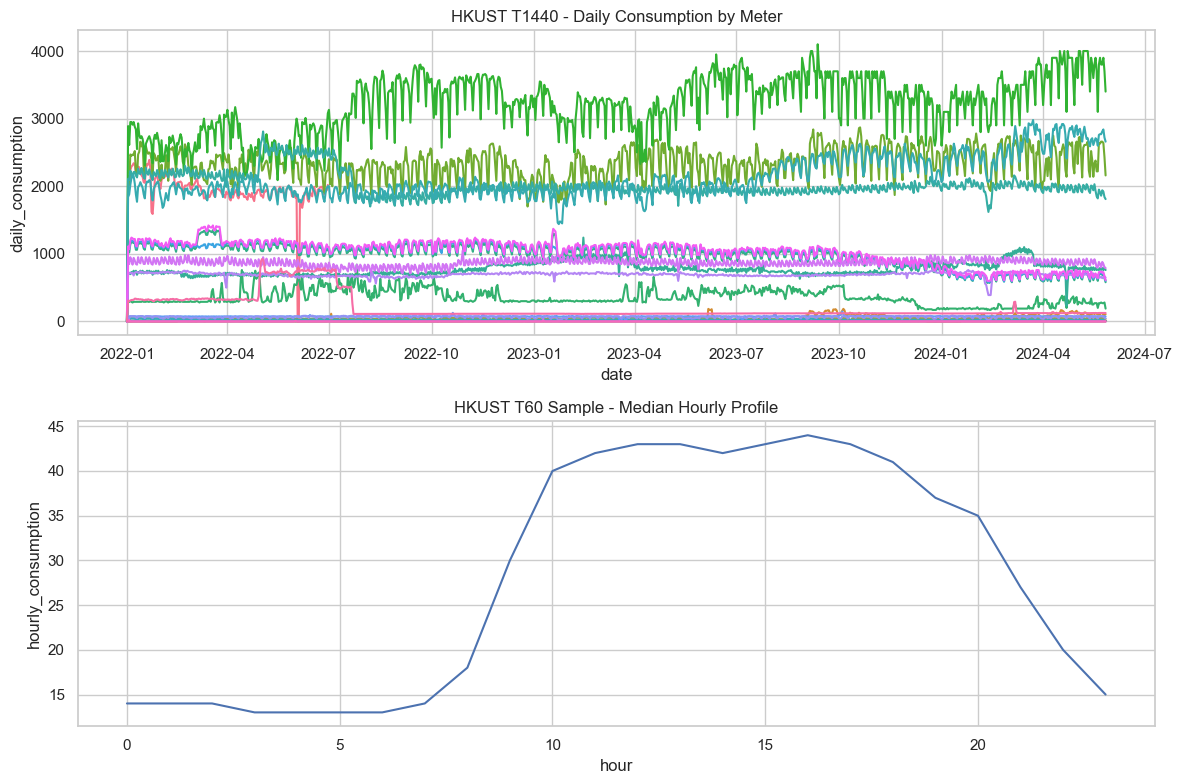

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
daily_by_meter = hkust_t1440.groupby(["date", "meter_id"], as_index=False)["daily_consumption"].sum()
sns.lineplot(data=daily_by_meter, x="date", y="daily_consumption", hue="meter_id", legend=False, ax=axes[0])
axes[0].set_title("HKUST T1440 - Daily Consumption by Meter")

sns.lineplot(data=t60_sample.dropna(subset=["hourly_consumption"]), x="hour", y="hourly_consumption", estimator="median", errorbar=None, ax=axes[1])
axes[1].set_title("HKUST T60 Sample - Median Hourly Profile")
plt.tight_layout()
plt.show()

## 3. Integrasi Akhir: HKUST T1440 + HKO Daily Weather

In [9]:
energy_daily = (
    hkust_t1440[(hkust_t1440["date"] >= PROJECT_START) & (hkust_t1440["date"] <= PROJECT_END)]
    .groupby("date")
    .agg(
        meter_count=("meter_id", "nunique"),
        valid_daily_consumption_count=("daily_consumption", "count"),
        total_daily_consumption=("daily_consumption", lambda s: s.sum(min_count=1)),
        mean_daily_consumption=("daily_consumption", "mean"),
        median_daily_consumption=("daily_consumption", "median"),
        max_meter_daily_consumption=("daily_consumption", "max"),
        missing_daily_consumption_count=("daily_consumption", lambda s: int(s.isna().sum())),
    )
    .reset_index()
)

combined = energy_daily.merge(hko_weather, on="date", how="left")
combined["weekday"] = combined["date"].dt.day_name()
combined["is_weekend"] = combined["date"].dt.dayofweek.ge(5).astype(int)
combined["month"] = combined["date"].dt.month
combined["year"] = combined["date"].dt.year

combined.shape, combined.head()

((878, 29),
         date  meter_count  valid_daily_consumption_count  \
 0 2022-01-01           26                              0   
 1 2022-01-02           26                             25   
 2 2022-01-03           26                             26   
 3 2022-01-04           26                             25   
 4 2022-01-05           26                             26   
 
    total_daily_consumption  mean_daily_consumption  median_daily_consumption  \
 0                      NaN                     NaN                       NaN   
 1             17328.700000              693.148000                     290.0   
 2             16845.005868              647.884841                     182.0   
 3             18646.600000              745.864000                     300.0   
 4             18815.407715              723.669527                     183.5   
 
    max_meter_daily_consumption  missing_daily_consumption_count  \
 0                          NaN                               26

In [10]:
display(combined.isna().sum().sort_values(ascending=False).head(12))
display(combined[[
    "total_daily_consumption",
    "mean_temperature_c",
    "relative_humidity_pct",
    "rainfall_mm",
    "global_solar_radiation_mj_m2",
    "mean_wind_speed_kmh",
]].describe().T)

rainfall_mm                                  5
rainfall_mm_completeness                     5
median_daily_consumption                     1
total_daily_consumption                      1
mean_daily_consumption                       1
global_solar_radiation_mj_m2_completeness    1
global_solar_radiation_mj_m2                 1
max_meter_daily_consumption                  1
mean_temperature_c                           0
meter_count                                  0
valid_daily_consumption_count                0
missing_daily_consumption_count              0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
total_daily_consumption,877.0,16251.134197,1191.582316,12817.601909,15471.60,16245.085006,16792.302898,19186.256754
mean_temperature_c,878.0,23.219818,5.319491,6.800000,18.90,23.900000,28.100000,32.200000
relative_humidity_pct,878.0,79.179954,10.919712,29.000000,73.00,81.000000,87.000000,98.000000
rainfall_mm,873.0,5.130584,18.290630,0.000000,0.00,0.000000,1.000000,256.000000
global_solar_radiation_mj_m2,877.0,14.125131,7.296315,0.990000,7.72,14.550000,20.070000,28.100000
mean_wind_speed_kmh,878.0,9.493850,5.568177,1.700000,5.60,8.000000,11.900000,37.600000


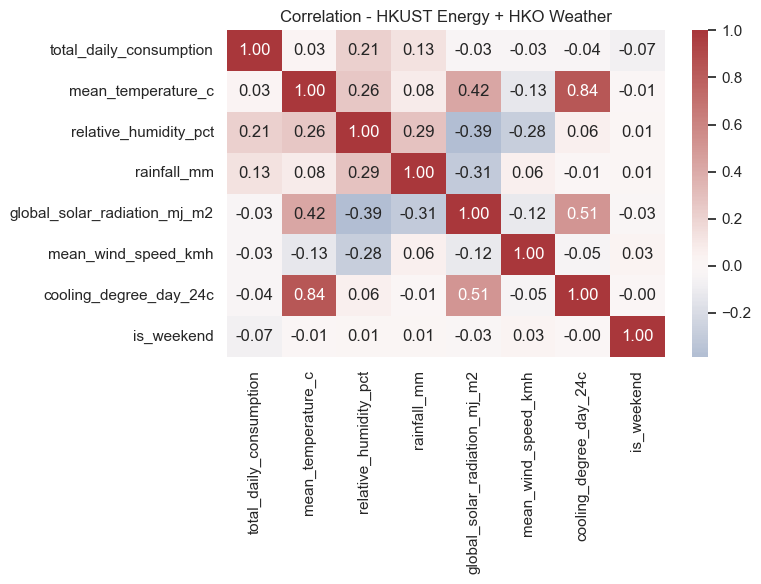

In [11]:
corr_cols = [
    "total_daily_consumption",
    "mean_temperature_c",
    "relative_humidity_pct",
    "rainfall_mm",
    "global_solar_radiation_mj_m2",
    "mean_wind_speed_kmh",
    "cooling_degree_day_24c",
    "is_weekend",
]
corr = combined[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation - HKUST Energy + HKO Weather")
plt.tight_layout()
plt.show()

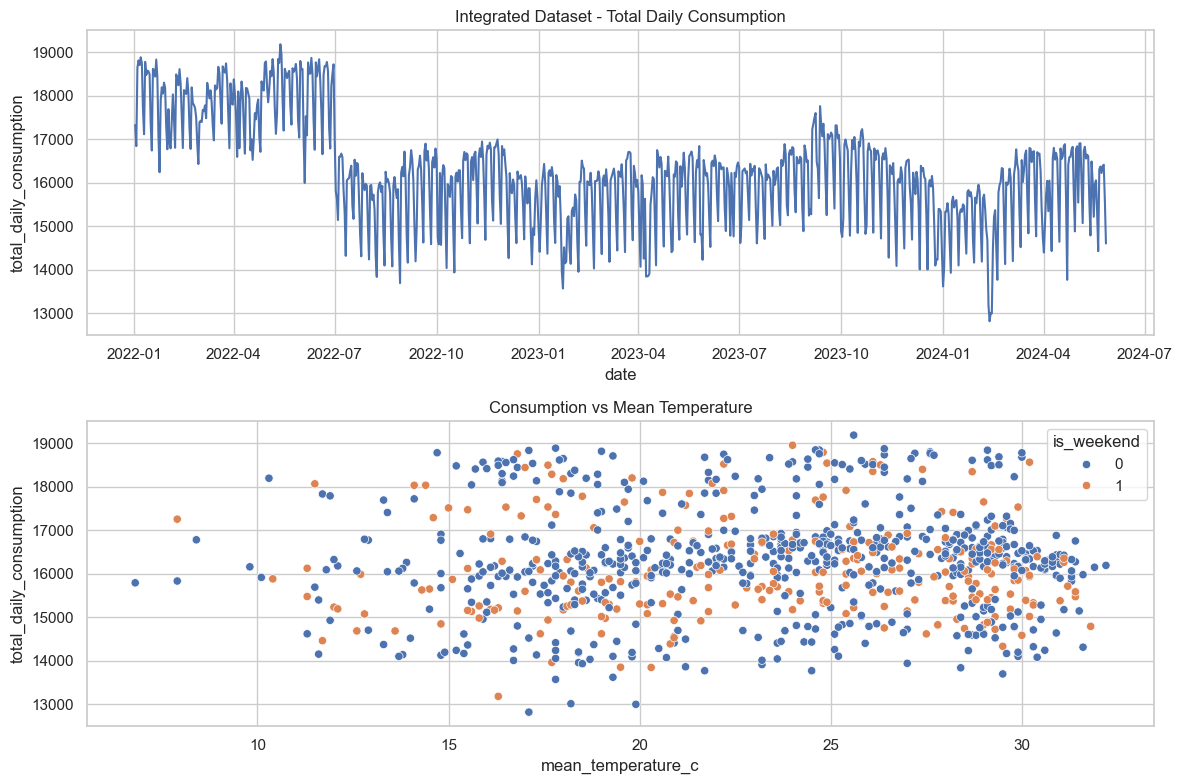

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
sns.lineplot(data=combined, x="date", y="total_daily_consumption", ax=axes[0])
axes[0].set_title("Integrated Dataset - Total Daily Consumption")
sns.scatterplot(data=combined, x="mean_temperature_c", y="total_daily_consumption", hue="is_weekend", ax=axes[1])
axes[1].set_title("Consumption vs Mean Temperature")
plt.tight_layout()
plt.show()

## 4. Catatan Interpretasi Awal

- Dataset HKO lengkap untuk periode proyek, kecuali rainfall dan solar radiation yang memiliki sedikit missing value.
- HKUST T1440 cocok sebagai baseline harian, tetapi hanya mencakup 26 meter sehingga belum mewakili seluruh kampus.
- Hubungan cuaca terhadap total konsumsi agregat cenderung lemah pada eksplorasi awal. Untuk tugas besar, analisis sebaiknya turun ke level meter/gedung/zona yang lebih spesifik.
- Integrasi akhir sudah memenuhi arah OSEMN: raw data terpisah, cleaning eksplisit, fitur waktu/cuaca tersedia, dan dataset siap untuk EDA, anomaly detection, atau forecasting sederhana.